✅ All libraries loaded!
   hour  day_of_week  vehicle_count  avg_speed_kmh  weather  incident  \
0     6            6             78           48.1        0         0   
1    19            0              5           40.3        0         1   
2    14            1             39           49.7        0         0   
3    10            5             54           53.5        0         0   
4     7            5            102           17.6        0         1   
5    20            4              5           54.8        0         0   
6     6            5            113           10.9        1         1   
7    18            2              5           32.7        0         1   
8    22            6              5           54.4        1         0   
9    10            3             97           31.4        0         0   

  congestion  
0     Medium  
1     Medium  
2     Medium  
3        Low  
4       High  
5        Low  
6       High  
7     Medium  
8        Low  
9     Medium  

📊 Data

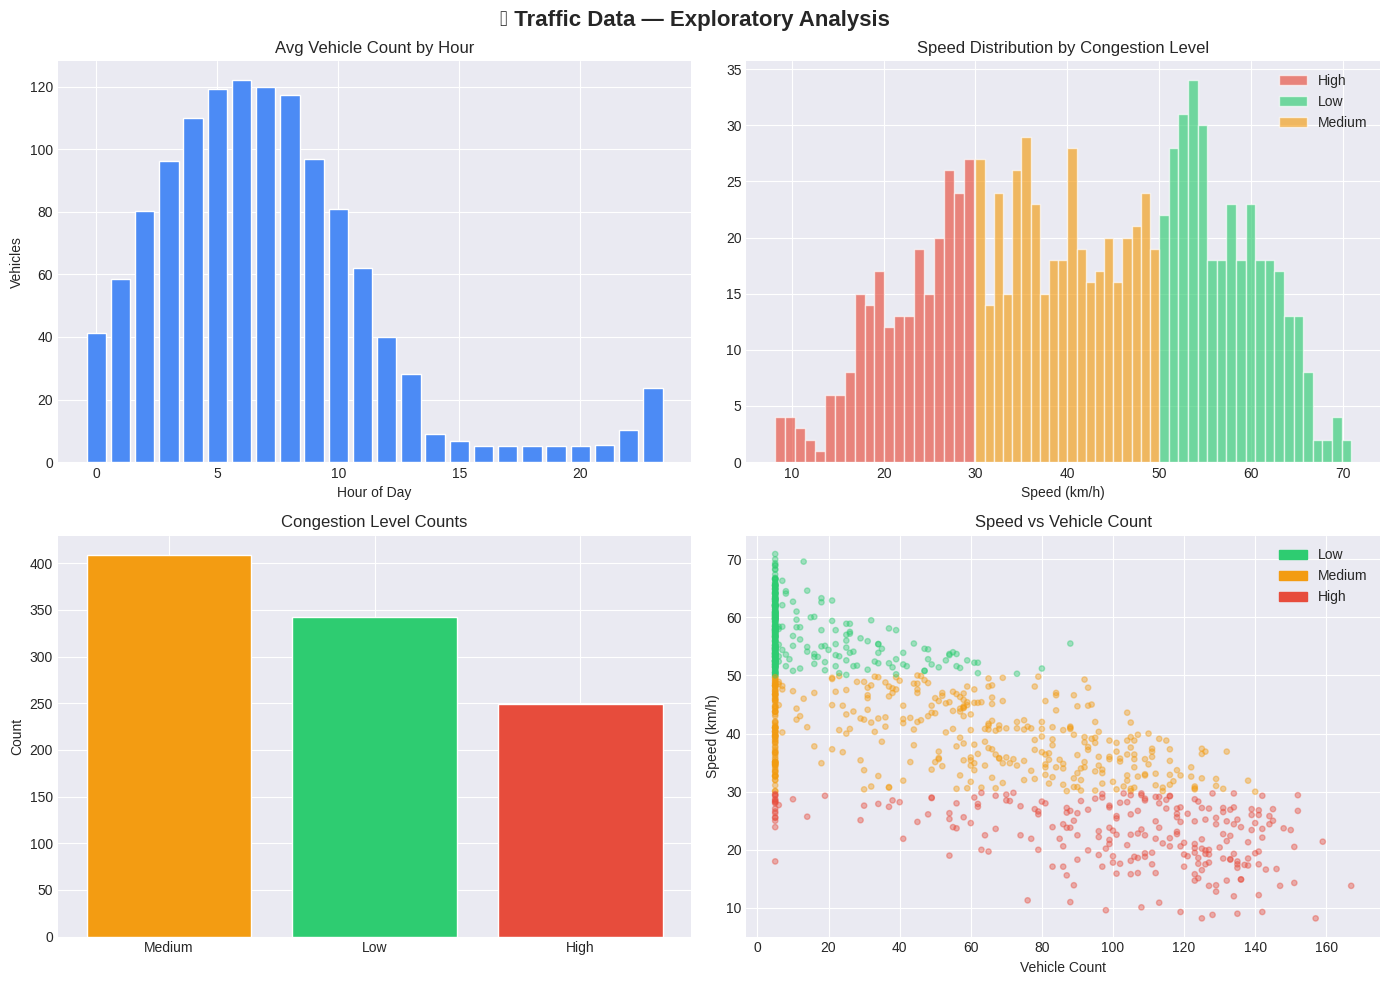

✅ EDA plots saved to eda_traffic.png


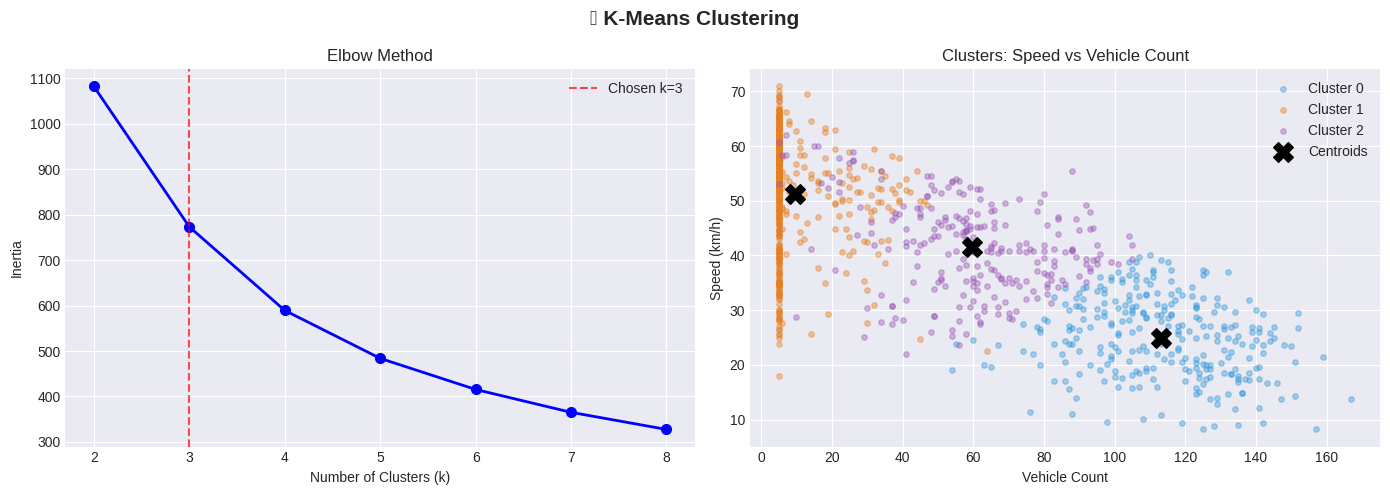


📌 Cluster Profiles:
         vehicle_count  avg_speed_kmh  hour
cluster                                    
0                113.1           25.0   5.9
1                  9.5           51.3  17.9
2                 59.5           41.5   5.1

Congestion distribution per cluster:
congestion  High  Low  Medium
cluster                      
0            203    0      77
1             22  302     152
2             24   40     180
✅ Random Forest Accuracy: 99.60%

Classification Report:
              precision    recall  f1-score   support

        High       1.00      1.00      1.00        62
         Low       0.99      1.00      0.99        86
      Medium       1.00      0.99      1.00       102

    accuracy                           1.00       250
   macro avg       1.00      1.00      1.00       250
weighted avg       1.00      1.00      1.00       250



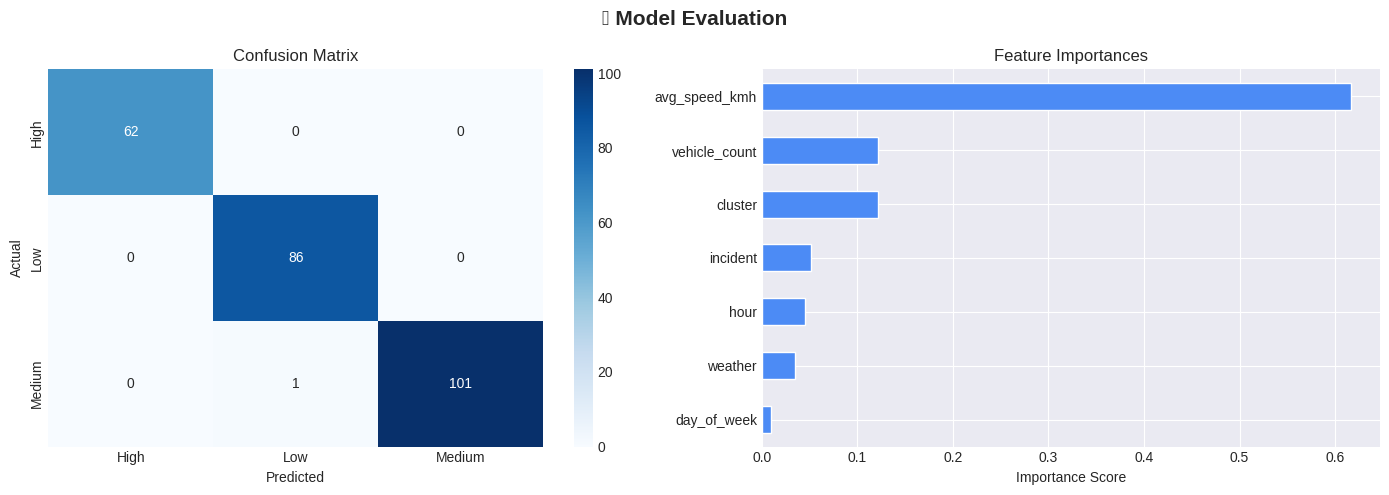

✅ Evaluation plots saved to model_evaluation.png
Example 1 — Rush hour, many vehicles, slow traffic

🚦 Predicted Congestion: High  (cluster 0)
   High   : ████████████████████ 100.0%
   Low    :                      0.0%
   Medium :                      0.0%

Example 2 — Late night, few vehicles, fast traffic

🚦 Predicted Congestion: Low  (cluster 2)
   High   :                      0.0%
   Low    : ███████████████████  98.7%
   Medium :                      1.3%

Example 3 — Afternoon with an incident + fog

🚦 Predicted Congestion: High  (cluster 0)
   High   : ██████████████████   94.0%
   Low    :                      0.0%
   Medium : █                    6.0%


In [1]:
# ============================================================
# 🚗 Intelligent Traffic System: Clustering + Prediction
# ============================================================

# ─────────────────────────────────────────────────────────────
# CELL 1 — Install & Import Libraries
# ─────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

import warnings
warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8-darkgrid")
print("✅ All libraries loaded!")


# ─────────────────────────────────────────────────────────────
# CELL 2 — Generate Synthetic Traffic Dataset
# ─────────────────────────────────────────────────────────────
np.random.seed(42)
n_samples = 1000

hours      = np.random.randint(0, 24, n_samples)
day_of_week= np.random.randint(0, 7,  n_samples)   # 0=Mon … 6=Sun
vehicle_count = (
    50
    + 80  * np.sin(np.pi * hours / 12)             # time-of-day curve
    - 30  * (day_of_week >= 5)                      # weekend dip
    + np.random.normal(0, 15, n_samples)
).clip(5, 200).astype(int)

avg_speed = (
    60
    - 0.25 * vehicle_count
    + np.random.normal(0, 5, n_samples)
).clip(5, 80)

weather_code = np.random.choice([0, 1, 2], n_samples, p=[0.6, 0.3, 0.1])  # 0=clear,1=rain,2=fog
weather_speed_penalty = np.where(weather_code == 1, -8,
                         np.where(weather_code == 2, -15, 0))
avg_speed = (avg_speed + weather_speed_penalty).clip(5, 80)

incident    = np.random.choice([0, 1], n_samples, p=[0.85, 0.15])
avg_speed   = np.where(incident == 1, avg_speed * 0.6, avg_speed).clip(5, 80)

# Congestion label  (ground truth for supervised learning)
def label_congestion(speed):
    if speed >= 50: return "Low"
    elif speed >= 30: return "Medium"
    else: return "High"

congestion_label = [label_congestion(s) for s in avg_speed]

df = pd.DataFrame({
    "hour":          hours,
    "day_of_week":   day_of_week,
    "vehicle_count": vehicle_count,
    "avg_speed_kmh": avg_speed.round(1),
    "weather":       weather_code,          # 0 clear | 1 rain | 2 fog
    "incident":      incident,
    "congestion":    congestion_label
})

print(df.head(10))
print(f"\n📊 Dataset shape: {df.shape}")
print("\nCongestion distribution:\n", df["congestion"].value_counts())


# ─────────────────────────────────────────────────────────────
# CELL 3 — Exploratory Data Analysis (EDA)
# ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("🚗 Traffic Data — Exploratory Analysis", fontsize=16, fontweight="bold")

# 3a. Vehicle count by hour
hourly_avg = df.groupby("hour")["vehicle_count"].mean()
axes[0, 0].bar(hourly_avg.index, hourly_avg.values, color="#4C8BF5", edgecolor="white")
axes[0, 0].set_title("Avg Vehicle Count by Hour")
axes[0, 0].set_xlabel("Hour of Day")
axes[0, 0].set_ylabel("Vehicles")

# 3b. Speed distribution per congestion level
colors = {"Low": "#2ecc71", "Medium": "#f39c12", "High": "#e74c3c"}
for level, grp in df.groupby("congestion"):
    axes[0, 1].hist(grp["avg_speed_kmh"], bins=20, alpha=0.65,
                    label=level, color=colors[level], edgecolor="white")
axes[0, 1].set_title("Speed Distribution by Congestion Level")
axes[0, 1].set_xlabel("Speed (km/h)")
axes[0, 1].legend()

# 3c. Congestion counts
cong_counts = df["congestion"].value_counts()
axes[1, 0].bar(cong_counts.index, cong_counts.values,
               color=[colors[k] for k in cong_counts.index], edgecolor="white")
axes[1, 0].set_title("Congestion Level Counts")
axes[1, 0].set_ylabel("Count")

# 3d. Speed vs Vehicle Count scatter
scatter_colors = df["congestion"].map(colors)
axes[1, 1].scatter(df["vehicle_count"], df["avg_speed_kmh"],
                   c=scatter_colors, alpha=0.4, s=15)
axes[1, 1].set_title("Speed vs Vehicle Count")
axes[1, 1].set_xlabel("Vehicle Count")
axes[1, 1].set_ylabel("Speed (km/h)")

from matplotlib.patches import Patch
legend_els = [Patch(color=v, label=k) for k, v in colors.items()]
axes[1, 1].legend(handles=legend_els)

plt.tight_layout()
plt.savefig("eda_traffic.png", dpi=150)
plt.show()
print("✅ EDA plots saved to eda_traffic.png")


# ─────────────────────────────────────────────────────────────
# CELL 4 — Unsupervised Learning: K-Means Clustering
# ─────────────────────────────────────────────────────────────
cluster_features = ["vehicle_count", "avg_speed_kmh", "hour"]
X_cluster = df[cluster_features].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

# Elbow method to choose k
inertia = []
k_range = range(2, 9)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("🔵 K-Means Clustering", fontsize=15, fontweight="bold")

# Elbow curve
axes[0].plot(list(k_range), inertia, "bo-", linewidth=2, markersize=7)
axes[0].axvline(x=3, color="red", linestyle="--", alpha=0.7, label="Chosen k=3")
axes[0].set_title("Elbow Method")
axes[0].set_xlabel("Number of Clusters (k)")
axes[0].set_ylabel("Inertia")
axes[0].legend()

# Final clustering with k=3
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df["cluster"] = kmeans.fit_predict(X_scaled)

# Scatter: speed vs vehicles, colored by cluster
palette = {0: "#3498db", 1: "#e67e22", 2: "#9b59b6"}
for c, grp in df.groupby("cluster"):
    axes[1].scatter(grp["vehicle_count"], grp["avg_speed_kmh"],
                    c=palette[c], alpha=0.4, s=15, label=f"Cluster {c}")

centers = scaler.inverse_transform(kmeans.cluster_centers_)
axes[1].scatter(centers[:, 0], centers[:, 1],
                s=200, c="black", marker="X", zorder=5, label="Centroids")
axes[1].set_title("Clusters: Speed vs Vehicle Count")
axes[1].set_xlabel("Vehicle Count")
axes[1].set_ylabel("Speed (km/h)")
axes[1].legend()

plt.tight_layout()
plt.savefig("clustering_traffic.png", dpi=150)
plt.show()

# Cluster summary
print("\n📌 Cluster Profiles:")
print(df.groupby("cluster")[["vehicle_count","avg_speed_kmh","hour"]].mean().round(1))
print("\nCongestion distribution per cluster:")
print(pd.crosstab(df["cluster"], df["congestion"]))


# ─────────────────────────────────────────────────────────────
# CELL 5 — Supervised Learning: Random Forest Classifier
# ─────────────────────────────────────────────────────────────
le = LabelEncoder()
df["congestion_enc"] = le.fit_transform(df["congestion"])   # High=0, Low=1, Medium=2

feature_cols = ["hour", "day_of_week", "vehicle_count",
                "avg_speed_kmh", "weather", "incident", "cluster"]
X = df[feature_cols]
y = df["congestion_enc"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

rf = RandomForestClassifier(n_estimators=150, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

acc = accuracy_score(y_test, y_pred)
print(f"✅ Random Forest Accuracy: {acc*100:.2f}%\n")
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))


# ─────────────────────────────────────────────────────────────
# CELL 6 — Model Evaluation Plots
# ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("📈 Model Evaluation", fontsize=15, fontweight="bold")

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=le.classes_, yticklabels=le.classes_, ax=axes[0])
axes[0].set_title("Confusion Matrix")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

# Feature importance
importances = pd.Series(rf.feature_importances_, index=feature_cols).sort_values()
importances.plot(kind="barh", ax=axes[1], color="#4C8BF5", edgecolor="white")
axes[1].set_title("Feature Importances")
axes[1].set_xlabel("Importance Score")

plt.tight_layout()
plt.savefig("model_evaluation.png", dpi=150)
plt.show()
print("✅ Evaluation plots saved to model_evaluation.png")


# ─────────────────────────────────────────────────────────────
# CELL 7 — Live Prediction Function (try your own inputs!)
# ─────────────────────────────────────────────────────────────
def predict_congestion(hour, day_of_week, vehicle_count,
                       avg_speed_kmh, weather, incident):
    """
    Predict congestion level for a new traffic observation.

    weather  : 0=clear  1=rain  2=fog
    incident : 0=none   1=incident present
    """
    # Determine cluster for the new sample
    sample_for_cluster = scaler.transform([[vehicle_count, avg_speed_kmh, hour]])
    cluster_id = kmeans.predict(sample_for_cluster)[0]

    sample = pd.DataFrame([[hour, day_of_week, vehicle_count,
                            avg_speed_kmh, weather, incident, cluster_id]],
                          columns=feature_cols)

    pred_enc  = rf.predict(sample)[0]
    pred_prob = rf.predict_proba(sample)[0]
    label     = le.inverse_transform([pred_enc])[0]

    print(f"\n🚦 Predicted Congestion: {label}  (cluster {cluster_id})")
    for cls, prob in zip(le.classes_, pred_prob):
        bar = "█" * int(prob * 20)
        print(f"   {cls:7s}: {bar:<20} {prob*100:.1f}%")

# ── Example predictions ──────────────────────────────────────
print("=" * 50)
print("Example 1 — Rush hour, many vehicles, slow traffic")
predict_congestion(hour=8, day_of_week=1, vehicle_count=175,
                   avg_speed_kmh=18, weather=1, incident=0)

print("\nExample 2 — Late night, few vehicles, fast traffic")
predict_congestion(hour=2, day_of_week=3, vehicle_count=20,
                   avg_speed_kmh=68, weather=0, incident=0)

print("\nExample 3 — Afternoon with an incident + fog")
predict_congestion(hour=15, day_of_week=0, vehicle_count=120,
                   avg_speed_kmh=22, weather=2, incident=1)